In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 加载数据（网络不通就用本地文件）
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# 填充年龄（复用昨天的技巧）
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# ---- 创建新特征 ----
# 1. 家庭规模 = 兄弟姐妹/配偶数 + 父母/子女数 + 自己
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. 从名字里提取“称谓”（Mr, Mrs, Miss, Master等）
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
#以后在正则表达式里想匹配 . 这个符号时，用 r'\.' 最安全

# 把少见称谓合并为 'Other'
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Other')
# 把法语称谓和Ms统一
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

print("新特征预览：")
print(df[['Name', 'Title', 'FamilySize']].head(10))

新特征预览：
                                                Name   Title  FamilySize
0                            Braund, Mr. Owen Harris      Mr           2
1  Cumings, Mrs. John Bradley (Florence Briggs Th...     Mrs           2
2                             Heikkinen, Miss. Laina    Miss           1
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)     Mrs           2
4                           Allen, Mr. William Henry      Mr           1
5                                   Moran, Mr. James      Mr           1
6                            McCarthy, Mr. Timothy J      Mr           1
7                     Palsson, Master. Gosta Leonard  Master           5
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)     Mrs           3
9                Nasser, Mrs. Nicholas (Adele Achem)     Mrs           2


In [9]:
# 计算不同“性别”和“客舱等级”组合下的存活率
pivot = pd.pivot_table(df, values='Survived', index='Sex', columns='Pclass', aggfunc='mean')
print("===== 性别-客舱 存活率透视表 =====")
print(pivot)

# 再做一个：不同“称谓”和“客舱等级”的平均年龄
pivot_age = pd.pivot_table(df, values='Age', index='Title', columns='Pclass', aggfunc='mean')
print("\n===== 称谓-客舱 平均年龄透视表 =====")
print(pivot_age)

===== 性别-客舱 存活率透视表 =====
Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447

===== 称谓-客舱 平均年龄透视表 =====
Pclass          1          2          3
Title                                  
Master   5.306667   2.258889   8.015000
Miss    29.895833  22.928571  18.671569
Mr      40.724299  32.395604  27.391850
Mrs     39.767442  33.682927  31.476190
Other   46.866667  42.000000        NaN


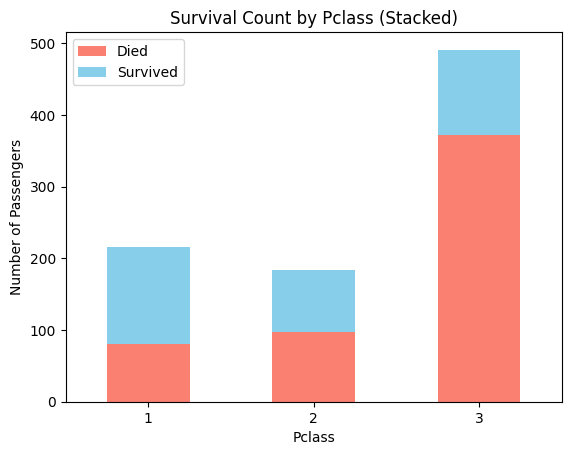

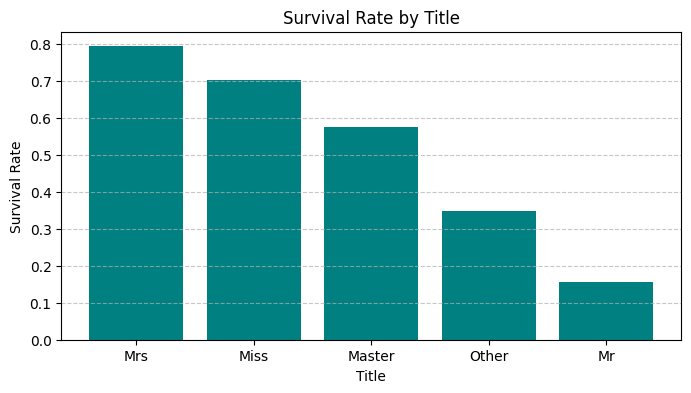

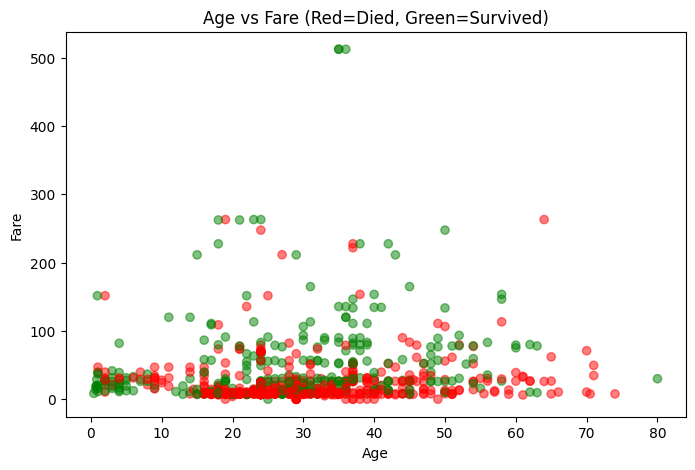

In [10]:
# 图1：堆叠柱状图 - 不同客舱等级的存活人数堆叠
survived_pclass = pd.crosstab(df['Pclass'], df['Survived'])
survived_pclass.plot(kind='bar', stacked=True, color=['salmon', 'skyblue'])
plt.title('Survival Count by Pclass (Stacked)')
plt.xlabel('Pclass')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)
plt.legend(['Died', 'Survived'])
plt.show()

# 图2：分组柱状图 - 不同称谓的存活率
title_survival = df.groupby('Title')['Survived'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.bar(title_survival.index, title_survival.values, color='teal')
plt.title('Survival Rate by Title')
plt.xlabel('Title')
plt.ylabel('Survival Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 图3：散点图 - 年龄 vs 票价，按存活与否着色
colors = df['Survived'].map({0: 'red', 1: 'green'})
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Fare'], c=colors, alpha=0.5)
plt.title('Age vs Fare (Red=Died, Green=Survived)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()